<a href="https://colab.research.google.com/github/fartech00/01/blob/main/ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://drive.google.com/file/d/1DlnklDezpKBZYU2yaLk3hudSeGZSO1FB/view?usp=sharing

In [2]:
!pip install gdown

In [6]:

import gdown
import zipfile
import os

# ---------------- GOOGLE DRIVE LINK ----------------
url = "https://drive.google.com/file/d/1DlnklDezpKBZYU2yaLk3hudSeGZSO1FB/view?usp=sharing"

# ---------------- OUTPUT FILE ----------------
zip_file = "/content/dataset.zip"

# ---------------- EXTRACT FOLDER ----------------
extract_folder = "/content/dataset"

# ---------------- DOWNLOAD ----------------
gdown.download(
    url=url,
    output=zip_file,
    quiet=False,
    fuzzy=True
)

# ---------------- CREATE FOLDER ----------------
os.makedirs(extract_folder, exist_ok=True)

# ---------------- UNZIP ----------------
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("✅ Dataset yuklandi")

# ---------------- SHOW FILES ----------------
for root, dirs, files in os.walk(extract_folder):
    print(f"{root} --> {len(files)} files")

Downloading...
From: https://drive.google.com/uc?id=1DlnklDezpKBZYU2yaLk3hudSeGZSO1FB
To: /content/dataset.zip
100%|██████████| 12.3M/12.3M [00:00<00:00, 27.0MB/s]


✅ Dataset yuklandi
/content/dataset --> 0 files
/content/dataset/data --> 3 files
/content/dataset/data/debate --> 6 files


In [7]:
import numpy as np
import pandas as pd
import itertools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [8]:
# data
df=pd.read_csv('/content/dataset/data/news.csv')

df.shape
df.head(15)

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
5,6903,"Tehran, USA","\nI’m not an immigrant, but my grandparents ...",FAKE
6,7341,Girl Horrified At What She Watches Boyfriend D...,"Share This Baylee Luciani (left), Screenshot o...",FAKE
7,95,‘Britain’s Schindler’ Dies at 106,A Czech stockbroker who saved more than 650 Je...,REAL
8,4869,Fact check: Trump and Clinton at the 'commande...,Hillary Clinton and Donald Trump made some ina...,REAL
9,2909,Iran reportedly makes new push for uranium con...,Iranian negotiators reportedly have made a las...,REAL


In [ ]:
#labels
labels=df.label
labels.head()

0    FAKE
1    FAKE
2    REAL
3    FAKE
4    REAL
Name: label, dtype: object

In [ ]:
# Split the dataset
x_train,x_test,y_train,y_test=train_test_split(df['text'], labels, test_size=0.2, random_state=7)

In [ ]:
# TfidfVectorizer
tfidf_vectorizer=TfidfVectorizer(stop_words='english', max_df=0.7)

tfidf_train=tfidf_vectorizer.fit_transform(x_train)
tfidf_test=tfidf_vectorizer.transform(x_test)

In [ ]:
pac=PassiveAggressiveClassifier(max_iter=75)
pac.fit(tfidf_train,y_train)

y_pred=pac.predict(tfidf_test)
score=accuracy_score(y_test,y_pred)
print(f'Accuracy: {round(score*100,2)}%')

Accuracy: 92.9%


In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred, labels=['FAKE','REAL'])

array([[590,  48],
       [ 42, 587]])

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10
from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense

from sklearn.preprocessing import MinMaxScaler

In [10]:
df=pd.read_csv("/content/dataset/data/NSE-Tata-Global-Beverages-Limited.csv")
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


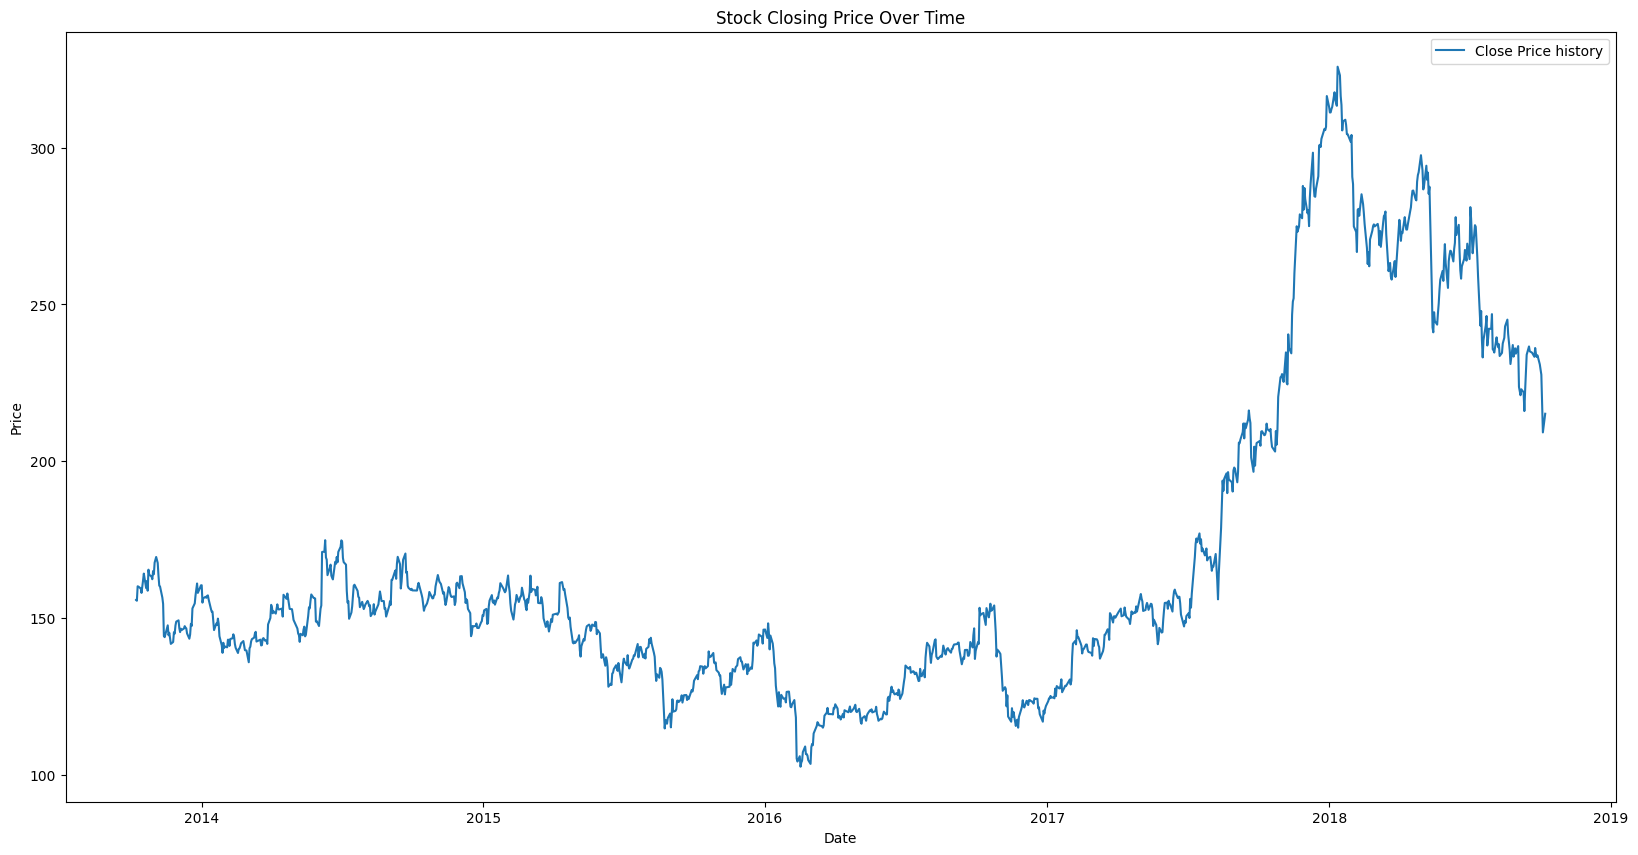

In [13]:
plt.plot(df["Close"], label='Close Price history')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Closing Price Over Time")
plt.legend()
plt.show()

In [14]:
data=df.sort_index(ascending=True,axis=0)
new_dataset=data.loc[:, ["Date", "Close"]].reset_index(drop=True).copy()
new_dataset["Close"] = new_dataset["Close"].astype(float)

In [15]:
new_dataset.index=new_dataset["Date"]
new_dataset.drop("Date",axis=1,inplace=True)

final_dataset=new_dataset[["Close"]].values
train_data=final_dataset[0:987,:]
valid_data=final_dataset[987:,:]

scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(final_dataset)

x_train_data,y_train_data=[],[]

for i in range(60,len(train_data)):
    x_train_data.append(scaled_data[i-60:i,0])
    y_train_data.append(scaled_data[i,0])

x_train_data,y_train_data=np.array(x_train_data),np.array(y_train_data)

x_train_data=np.reshape(x_train_data,(x_train_data.shape[0],x_train_data.shape[1],1))

In [16]:
lstm_model=Sequential()
lstm_model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train_data.shape[1],1)))
lstm_model.add(LSTM(units=50))
lstm_model.add(Dense(1))

inputs_data=new_dataset[len(new_dataset)-len(valid_data)-60:].values
inputs_data=inputs_data.reshape(-1,1)
inputs_data=scaler.transform(inputs_data)

lstm_model.compile(loss='mean_squared_error',optimizer='adam')
lstm_model.fit(x_train_data,y_train_data,epochs=1,batch_size=1,verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


927/927 - 24s - 26ms/step - loss: 0.0011


In [17]:
X_test=[]
for i in range(60,inputs_data.shape[0]):
    X_test.append(inputs_data[i-60:i,0])
X_test=np.array(X_test)

X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
predicted_closing_price=lstm_model.predict(X_test)
predicted_closing_price=scaler.inverse_transform(predicted_closing_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [18]:
lstm_model.save("/content/model/model.keras")

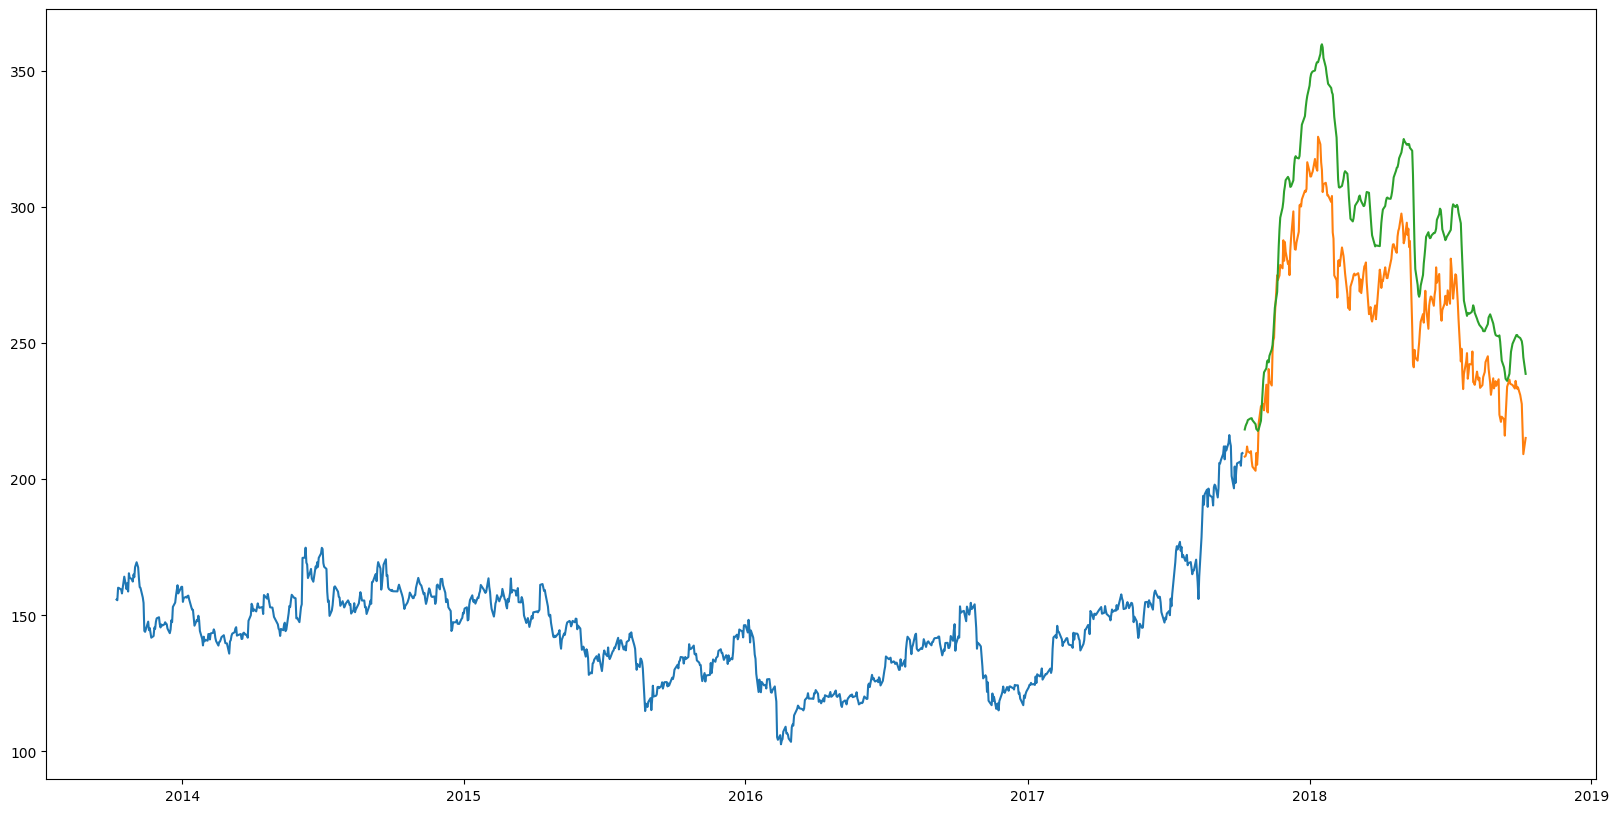

In [ ]:
train_data=new_dataset[:987]
valid_data=new_dataset[987:].copy()
valid_data.loc[:, "Predictions"] = predicted_closing_price
plt.plot(train_data["Close"])
plt.plot(valid_data[['Close',"Predictions"]])